# W1-D1: Metric Anomaly Detection
**Dataset:** NAB `realKnownCause/ambient_temperature_system_failure.csv`

**Ground Truth:** `2013-12-22 20:00:00`, `2014-04-13 09:00:00`

In [1]:
%pip install pandas numpy matplotlib scipy statsmodels scikit-learn joblib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

---
## Phase 1: EDA & Hieu Data (1.5h)

### 1.1 Load data, plot raw time series

In [3]:
# Load data
df = pd.read_csv('ambient_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()
df = df.asfreq('h')
df['value'] = df['value'].interpolate(method='linear')

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Frequency: Hourly (1H)')
print(f'Total data points: {len(df)}')

# Ground truth labels (tu NAB combined_labels.json)
anomaly_timestamps = [
    pd.Timestamp('2013-12-22 20:00:00'),
    pd.Timestamp('2014-04-13 09:00:00')
]
WINDOW_HOURS = 24
df['is_anomaly'] = False
for ts in anomaly_timestamps:
    mask = (df.index >= ts - pd.Timedelta(hours=WINDOW_HOURS)) & \
           (df.index <= ts + pd.Timedelta(hours=WINDOW_HOURS))
    df.loc[mask, 'is_anomaly'] = True
print(f'Ground truth anomaly points (+-{WINDOW_HOURS}h window): {df["is_anomaly"].sum()}')

Dataset shape: (7888, 1)
Date range: 2013-07-04 00:00:00 to 2014-05-28 15:00:00
Frequency: Hourly (1H)
Total data points: 7888
Ground truth anomaly points (+-24h window): 98


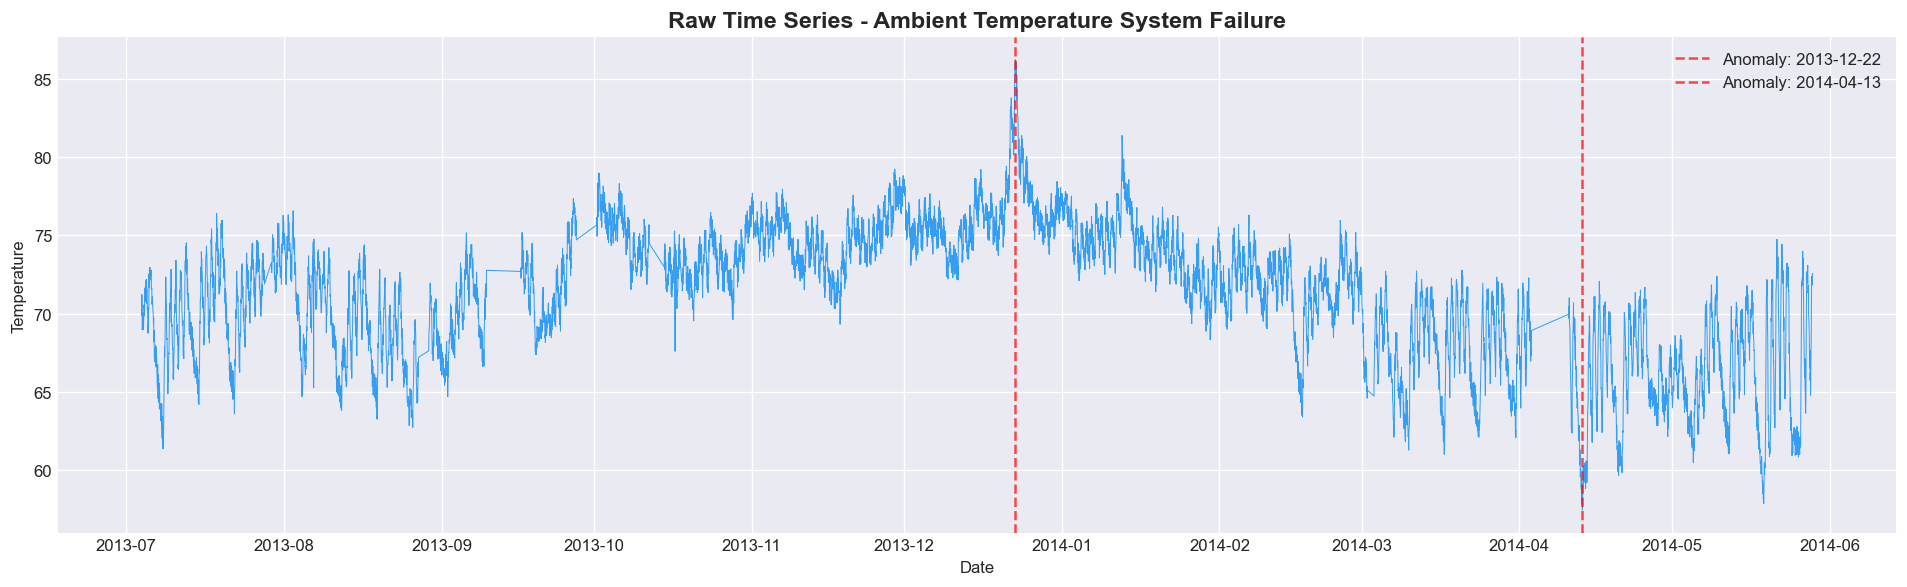

In [4]:
# Plot raw time series
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['value'], linewidth=0.6, color='#2196F3', alpha=0.9)
for ts in anomaly_timestamps:
    ax.axvline(x=ts, color='red', linestyle='--', alpha=0.7, label=f'Anomaly: {ts.date()}')
ax.set_title('Raw Time Series - Ambient Temperature System Failure', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
ax.legend()
plt.tight_layout()
plt.show()

### 1.2 Basic stats: mean, std, skewness, min, max

In [5]:
values = df['value'].dropna()
mean_val = values.mean()
std_val = values.std()
skew_val = stats.skew(values)
min_val = values.min()
max_val = values.max()

print('--- Basic Statistics ---')
print(f'Mean:     {mean_val:.4f}')
print(f'Std:      {std_val:.4f}')
print(f'Skewness: {skew_val:.4f}')
print(f'Min:      {min_val:.4f}')
print(f'Max:      {max_val:.4f}')
print()
if abs(skew_val) < 0.5:
    print('=> Near Gaussian (|skewness| < 0.5) -> 3-sigma OK')
elif abs(skew_val) < 1:
    print('=> Moderate skew (0.5-1) -> can than voi 3-sigma')
else:
    print('=> Heavily skewed (>1) -> KHONG dung 3-sigma truc tiep')

--- Basic Statistics ---
Mean:     71.2540
Std:      4.1553
Skewness: -0.4039
Min:      57.4584
Max:      86.2232

=> Near Gaussian (|skewness| < 0.5) -> 3-sigma OK


### 1.3 Plot histogram + density

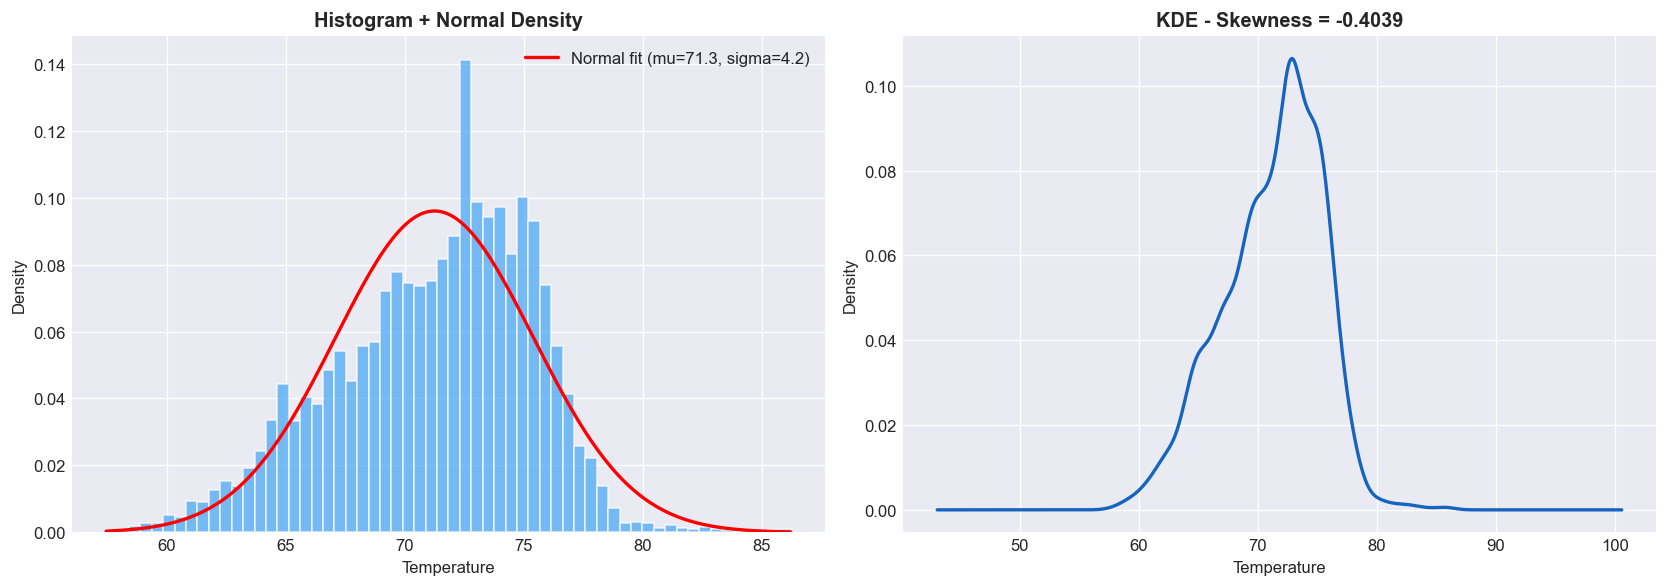


Skewness = -0.4039
Data gần Gaussian, hơi left-skewed nhung trong ngưỡng chấp nhận -> 3-sigma applicable


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + Normal fit
axes[0].hist(values, bins=60, density=True, alpha=0.7, color='#42A5F5', edgecolor='white')
x = np.linspace(values.min(), values.max(), 200)
pdf = stats.norm.pdf(x, mean_val, std_val)
axes[0].plot(x, pdf, 'r-', linewidth=2, label=f'Normal fit (mu={mean_val:.1f}, sigma={std_val:.1f})')
axes[0].set_title('Histogram + Normal Density', fontweight='bold')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Density')
axes[0].legend()

# KDE
values.plot.kde(ax=axes[1], color='#1565C0', linewidth=2)
axes[1].set_title(f'KDE - Skewness = {skew_val:.4f}', fontweight='bold')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Density')
plt.tight_layout()
plt.show()

print(f'\nSkewness = {skew_val:.4f}')
print('Data gần Gaussian, hơi left-skewed nhung trong ngưỡng chấp nhận -> 3-sigma applicable')

### 1.4 Plot ACF -> co seasonal khong? Period bao nhieu?

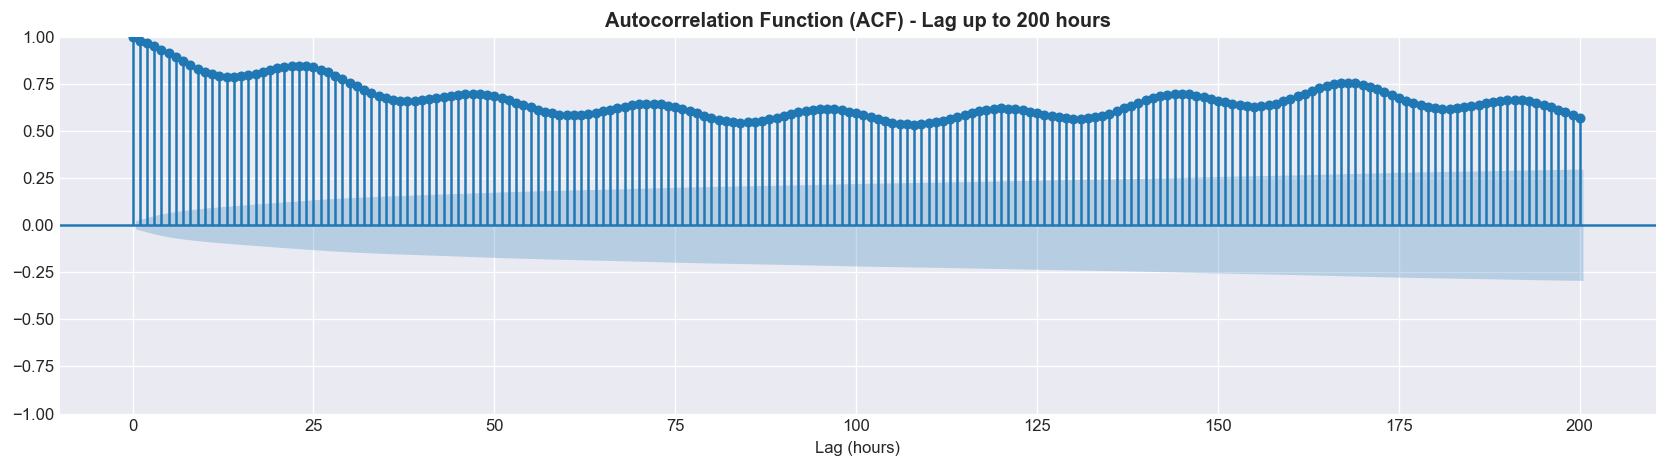

ACF cho thấy peaks tại lag 24, 48, 72, ...
=> DAILY SEASONAL PATTERN voi period = 24 (hourly data)


In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(values, lags=200, ax=ax, alpha=0.05)
ax.set_title('Autocorrelation Function (ACF) - Lag up to 200 hours', fontweight='bold')
ax.set_xlabel('Lag (hours)')
plt.tight_layout()
plt.show()

print('ACF cho thấy peaks tại lag 24, 48, 72, ...')
print('=> DAILY SEASONAL PATTERN voi period = 24 (hourly data)')

### 1.5 Kết luận

| Property | Value | Interpretation |
|----------|-------|----------------|
| Skewness | -0.40 | Near Gaussian, 3-sigma applicable |
| ACF | Peaks at lag 24, 48, 72... | Daily seasonal pattern (period=24) |
| Stationarity | Non-stationary | Long-term temperature trend (warm/cold months) |

**Data type:** Seasonal + near-Gaussian

**Best method:** STL Decomposition + 3-sigma on residual
- STL removes daily cycle -> anomaly detection tren residual
- Skewness đủ thấp để 3-sigma hoat động trên residuals
- Chọn STL + 3-sigma vù data có seasonal pattern rõ ràng

---
## Phase 2: Implement 2 Detectors (2h)

### Detector 1: STL Decomposition + 3-sigma on Residual

Chon vi data co daily seasonal pattern (period=24h). STL tach trend + seasonal + residual, sau do detect anomaly tren residual bang 3-sigma.

In [11]:
# STL Decomposition
stl = STL(df['value'], period=24, robust=True)
result = stl.fit()

residual = result.resid
resid_mean = np.mean(residual)
resid_std = np.std(residual)
threshold_stl = 3.0
anomalies_stl = np.abs(residual - resid_mean) > threshold_stl * resid_std
df['anomaly_stl'] = anomalies_stl

print(f'Residual mean: {resid_mean:.4f}')
print(f'Residual std:  {resid_std:.4f}')
print(f'Threshold:     +/-{threshold_stl * resid_std:.4f}')
print(f'Anomalies detected: {anomalies_stl.sum()}')

Residual mean: -0.0847
Residual std:  1.1210
Threshold:     +/-3.3629
Anomalies detected: 208


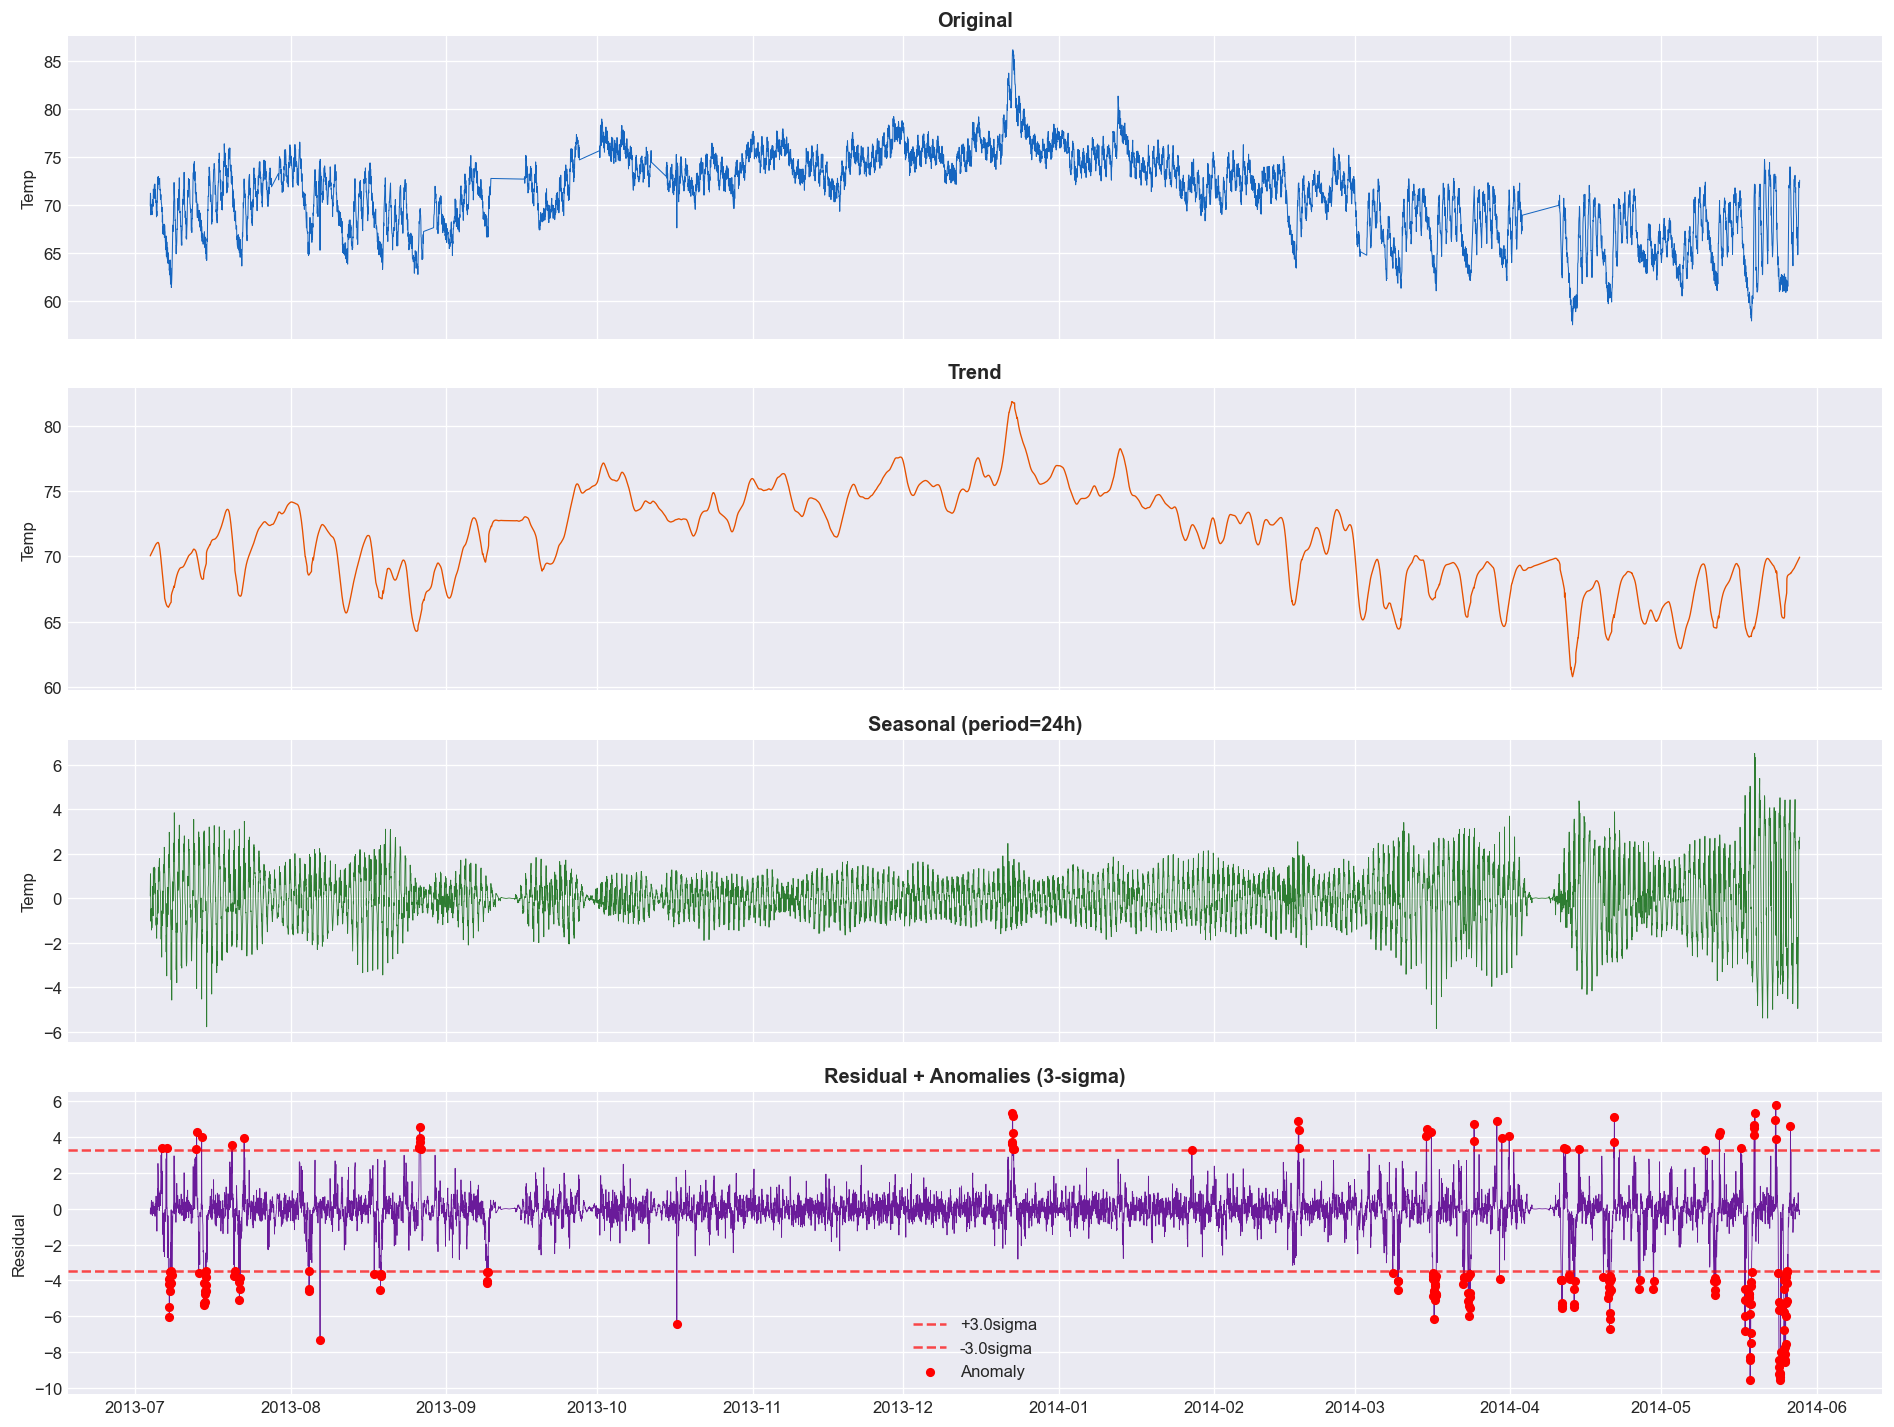

In [12]:
# Plot STL decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df.index, df['value'], linewidth=0.6, color='#1565C0')
axes[0].set_title('Original', fontweight='bold')
axes[0].set_ylabel('Temp')

axes[1].plot(df.index, result.trend, linewidth=0.8, color='#E65100')
axes[1].set_title('Trend', fontweight='bold')
axes[1].set_ylabel('Temp')

axes[2].plot(df.index, result.seasonal, linewidth=0.5, color='#2E7D32')
axes[2].set_title('Seasonal (period=24h)', fontweight='bold')
axes[2].set_ylabel('Temp')

axes[3].plot(df.index, residual, linewidth=0.5, color='#6A1B9A')
axes[3].axhline(resid_mean + threshold_stl * resid_std, color='red', linestyle='--', alpha=0.7, label=f'+{threshold_stl}sigma')
axes[3].axhline(resid_mean - threshold_stl * resid_std, color='red', linestyle='--', alpha=0.7, label=f'-{threshold_stl}sigma')
anom_idx = df.index[anomalies_stl]
axes[3].scatter(anom_idx, residual[anomalies_stl], color='red', s=20, zorder=5, label='Anomaly')
axes[3].set_title('Residual + Anomalies (3-sigma)', fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].legend()

plt.tight_layout()
plt.savefig('plot_04_stl_decomposition.png', bbox_inches='tight')
plt.show()

### Detector 2: Isolation Forest

Tạo feature table (11 features) rồi train Isolation Forest. Tune contamination: 0.01, 0.02, 0.05.

In [13]:
# Feature engineering (build_features tu section 8)
def build_features(series, timestamps, window=24):
    """Bien 1 metric time series thanh feature table cho ML model."""
    s = pd.Series(series.values, index=timestamps)
    features = pd.DataFrame({
        'value': s,
        'rolling_mean_24h': s.rolling(window).mean(),
        'rolling_std_24h': s.rolling(window).std(),
        'rolling_mean_96h': s.rolling(window * 4).mean(),
        'rate_of_change': s.diff(),
        'rate_of_change_6h': s.diff(6),
        'lag_1': s.shift(1),
        'lag_24': s.shift(window),
        'hour': s.index.hour,
        'is_weekend': (s.index.dayofweek >= 5).astype(int),
        'z_score': (s - s.rolling(window).mean()) / s.rolling(window).std().replace(0, 1e-10),
    })
    return features.dropna()

X_features = build_features(df['value'], df.index, window=24)
print(f'Feature table shape: {X_features.shape}')
print(f'Features ({len(X_features.columns)}):')
for col in X_features.columns:
    print(f'  - {col}')
print()
X_features.head()

Feature table shape: (7793, 11)
Features (11):
  - value
  - rolling_mean_24h
  - rolling_std_24h
  - rolling_mean_96h
  - rate_of_change
  - rate_of_change_6h
  - lag_1
  - lag_24
  - hour
  - is_weekend
  - z_score



,value,rolling_mean_24h,rolling_std_24h,rolling_mean_96h,rate_of_change,rate_of_change_6h,lag_1,lag_24,hour,is_weekend,z_score
timestamp,,,,,,,,,,,
2013-07-07 23:00:00,64.246634,64.706808,1.055497,68.812659,1.571845,0.103529,62.674789,67.163377,23,1,-0.435978
2013-07-08 00:00:00,62.480785,64.548687,1.093806,68.735575,-1.765848,-1.695157,64.246634,66.275684,0,0,-1.890556
2013-07-08 01:00:00,62.030554,64.384602,1.164627,68.639850,-0.450231,-1.126527,62.480785,65.968587,1,0,-2.021289
2013-07-08 02:00:00,63.411560,64.305233,1.163269,68.562076,1.381006,0.024662,62.030554,65.316423,2,0,-0.768242
2013-07-08 03:00:00,61.705110,64.150065,1.251836,68.486511,-1.706451,-2.285277,63.411560,65.429128,3,0,-1.953095


#### Tune contamination parameter: 0.01, 0.02, 0.05

In [14]:
y_true_aligned = df.loc[X_features.index, 'is_anomaly'].astype(int)
best_f1, best_cont = 0, 0.01
tune_results = []

print('=== Contamination Tuning ===')
print(f'{"cont":>6} | {"Precision":>9} | {"Recall":>6} | {"F1":>6} | {"FP":>4} | {"TP":>4} | {"FN":>4}')
print('-' * 55)

for cont in [0.01, 0.02, 0.05]:
    clf = IsolationForest(
        n_estimators=200,
        contamination=cont,
        max_features=1.0,
        random_state=42,
    )
    clf.fit(X_features)
    preds = clf.predict(X_features)
    y_pred = (preds == -1).astype(int)
    
    p = precision_score(y_true_aligned, y_pred, zero_division=0)
    r = recall_score(y_true_aligned, y_pred, zero_division=0)
    f1 = f1_score(y_true_aligned, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true_aligned, y_pred).ravel()
    
    print(f'{cont:>6.2f} | {p:>9.4f} | {r:>6.4f} | {f1:>6.4f} | {fp:>4} | {tp:>4} | {fn:>4}')
    tune_results.append({'contamination': cont, 'P': p, 'R': r, 'F1': f1, 'FP': fp, 'TP': tp, 'FN': fn})
    
    if f1 > best_f1:
        best_f1, best_cont = f1, cont

print(f'\nBest contamination: {best_cont} (F1={best_f1:.4f})')

=== Contamination Tuning ===
  cont | Precision | Recall |     F1 |   FP |   TP |   FN
-------------------------------------------------------
  0.01 |    0.6026 | 0.4796 | 0.5341 |   31 |   47 |   51
  0.02 |    0.4359 | 0.6939 | 0.5354 |   88 |   68 |   30
  0.05 |    0.2256 | 0.8980 | 0.3607 |  302 |   88 |   10

Best contamination: 0.02 (F1=0.5354)


In [15]:
# Train final model voi best contamination
clf_final = IsolationForest(
    n_estimators=200,
    contamination=best_cont,
    max_features=1.0,
    random_state=42,
)
clf_final.fit(X_features)
preds_final = clf_final.predict(X_features)
df['anomaly_if'] = False
df.loc[X_features.index, 'anomaly_if'] = (preds_final == -1)

# Save model artifact
joblib.dump(clf_final, 'isolation_forest_model.pkl')
print(f'Model saved: isolation_forest_model.pkl')
print(f'Anomalies detected by IF: {(preds_final == -1).sum()}')

Model saved: isolation_forest_model.pkl
Anomalies detected by IF: 156


### Evaluation - Cả 2 Detectors

Tính precision, recall, F1 dùng ground truth label từ NAB.

In [16]:
y_true_full = df['is_anomaly'].astype(int)

# Detector 1: STL + 3-sigma
y_pred_stl = df['anomaly_stl'].astype(int)
p_stl = precision_score(y_true_full, y_pred_stl, zero_division=0)
r_stl = recall_score(y_true_full, y_pred_stl, zero_division=0)
f1_stl = f1_score(y_true_full, y_pred_stl, zero_division=0)
tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_true_full, y_pred_stl).ravel()

# Detector 2: Isolation Forest
y_pred_if = df['anomaly_if'].astype(int)
p_if = precision_score(y_true_full, y_pred_if, zero_division=0)
r_if = recall_score(y_true_full, y_pred_if, zero_division=0)
f1_if = f1_score(y_true_full, y_pred_if, zero_division=0)
tn_i, fp_i, fn_i, tp_i = confusion_matrix(y_true_full, y_pred_if).ravel()

print('=== Detector 1: STL + 3-sigma ===')
print(f'  Precision: {p_stl:.4f}')
print(f'  Recall:    {r_stl:.4f}')
print(f'  F1:        {f1_stl:.4f}')
print(f'  TP={tp_s}, FP={fp_s}, FN={fn_s}, TN={tn_s}')
print()
print('=== Detector 2: Isolation Forest ===')
print(f'  Precision: {p_if:.4f}')
print(f'  Recall:    {r_if:.4f}')
print(f'  F1:        {f1_if:.4f}')
print(f'  TP={tp_i}, FP={fp_i}, FN={fn_i}, TN={tn_i}')

=== Detector 1: STL + 3-sigma ===
  Precision: 0.0625
  Recall:    0.1327
  F1:        0.0850
  TP=13, FP=195, FN=85, TN=7595

=== Detector 2: Isolation Forest ===
  Precision: 0.4359
  Recall:    0.6939
  F1:        0.5354
  TP=68, FP=88, FN=30, TN=7702


### Plot: Original series + anomalies highlighted (2 subplots)

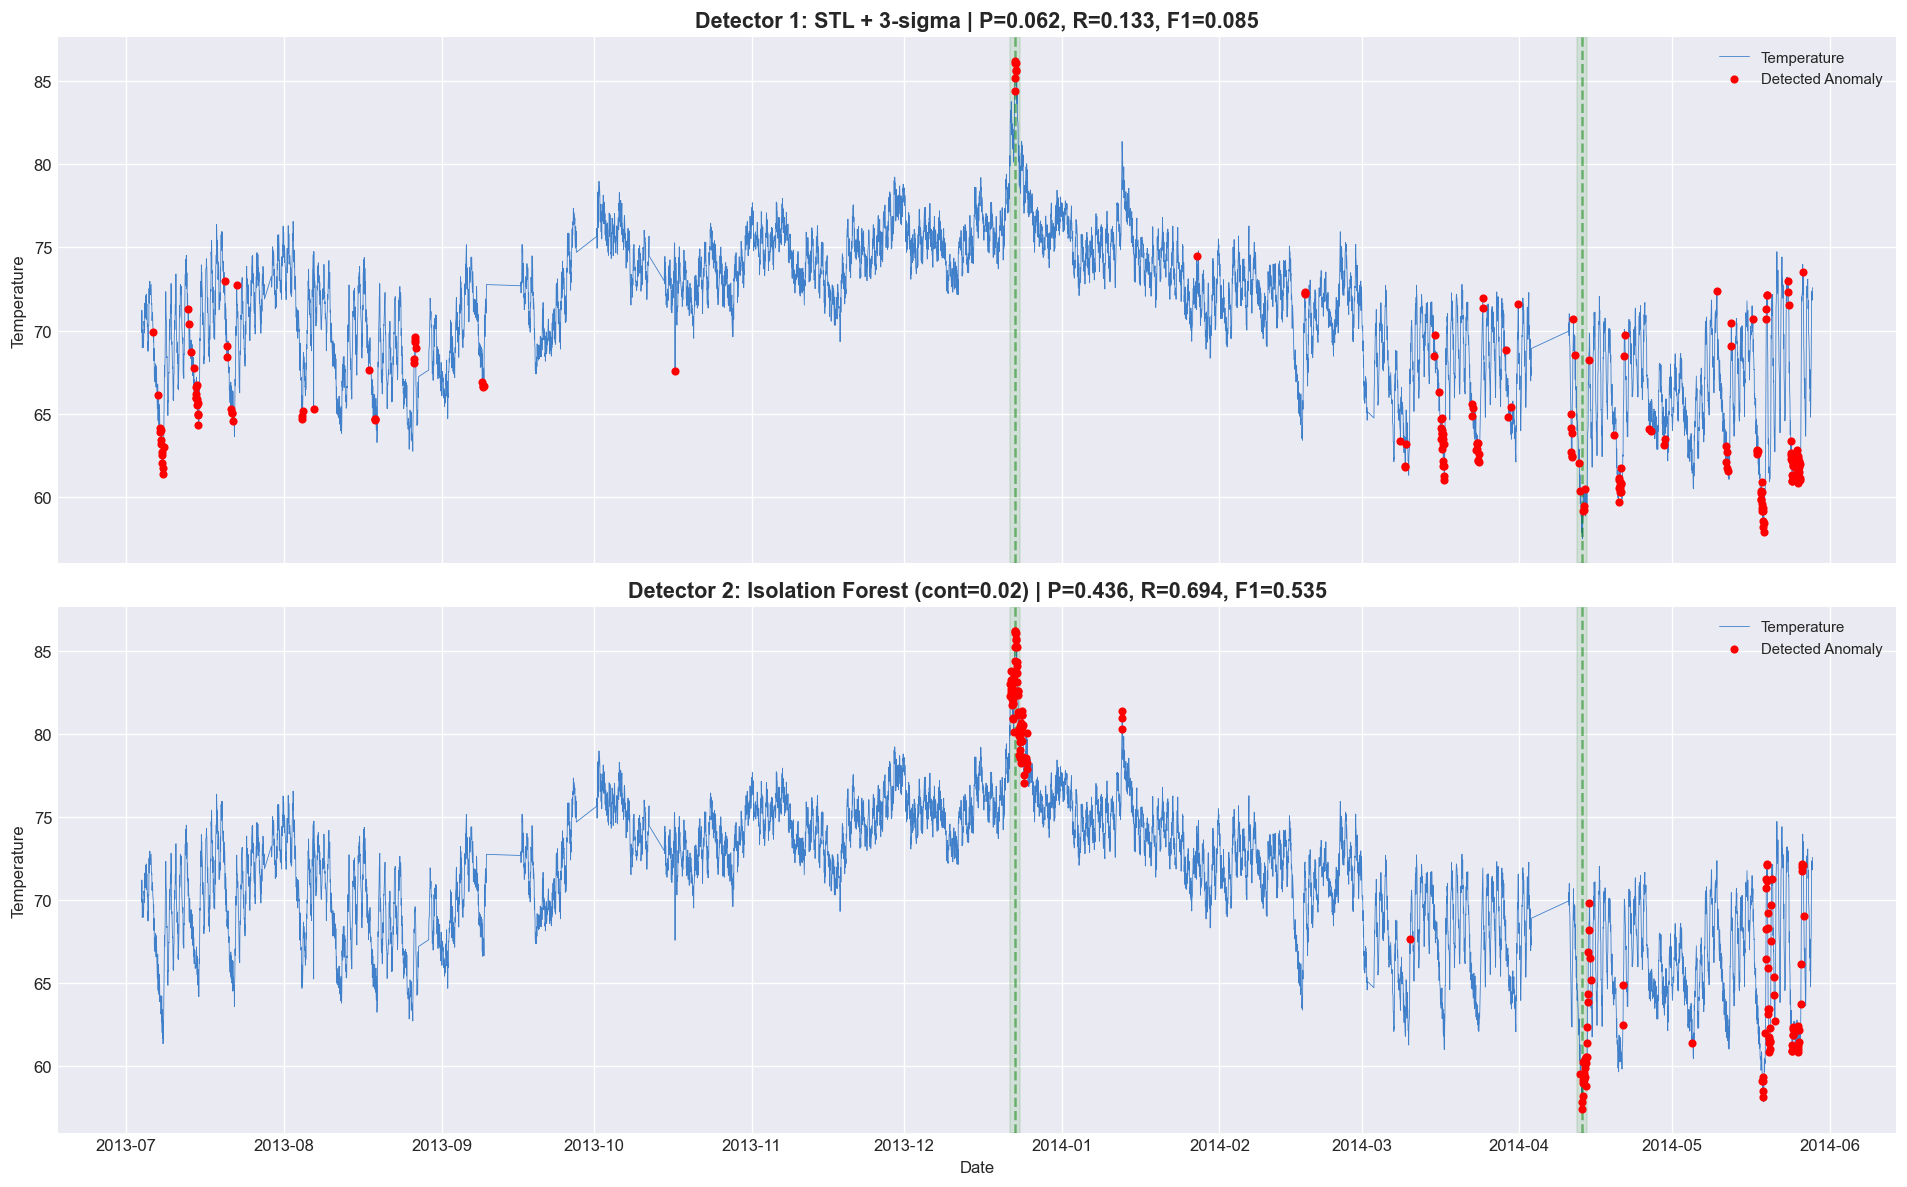

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for ax, title, anomaly_col, p, r, f1 in [
    (axes[0], 'Detector 1: STL + 3-sigma', 'anomaly_stl', p_stl, r_stl, f1_stl),
    (axes[1], f'Detector 2: Isolation Forest (cont={best_cont})', 'anomaly_if', p_if, r_if, f1_if)
]:
    ax.plot(df.index, df['value'], linewidth=0.5, color='#1565C0', alpha=0.8, label='Temperature')
    anom_idx = df.index[df[anomaly_col]]
    ax.scatter(anom_idx, df.loc[anom_idx, 'value'], color='red', s=15, zorder=5, label='Detected Anomaly')
    for ts in anomaly_timestamps:
        ax.axvspan(ts - pd.Timedelta(hours=WINDOW_HOURS),
                   ts + pd.Timedelta(hours=WINDOW_HOURS),
                   alpha=0.1, color='green')
        ax.axvline(x=ts, color='green', linestyle='--', alpha=0.5)
    ax.set_title(f'{title} | P={p:.3f}, R={r:.3f}, F1={f1:.3f}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Temperature')
    ax.legend(loc='upper right', fontsize=9)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('plot_05_detector_comparison.png', bbox_inches='tight')
plt.show()

---
## Phase 3: So Sánh & Reflection (1.5h)

### Bảng so sánh 2 detector

In [18]:
# Bang so sanh
comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1', 'False Alarms (FP)', 'True Positives (TP)'],
    'Detector 1 (STL + 3sigma)': [f'{p_stl:.4f}', f'{r_stl:.4f}', f'{f1_stl:.4f}', str(fp_s), str(tp_s)],
    'Detector 2 (IF)': [f'{p_if:.4f}', f'{r_if:.4f}', f'{f1_if:.4f}', str(fp_i), str(tp_i)],
})
comparison = comparison.set_index('Metric')
print(comparison.to_string())

                    Detector 1 (STL + 3sigma) Detector 2 (IF)
Metric                                                       
Precision                              0.0625          0.4359
Recall                                 0.1327          0.6939
F1                                     0.0850          0.5354
False Alarms (FP)                         195              88
True Positives (TP)                        13              68


### Tune threshold / window size / contamination (ít nhất 3 lần)

In [19]:
# === STL Threshold Tuning ===
print('=== STL Threshold Tuning ===')
print(f'{"threshold":>9} | {"Precision":>9} | {"Recall":>6} | {"F1":>6} | {"FP":>4} | {"TP":>4}')
print('-' * 50)
for thresh in [2.5, 3.0, 3.5]:
    anom_t = np.abs(residual - resid_mean) > thresh * resid_std
    y_pred_t = anom_t.astype(int)
    p_t = precision_score(y_true_full, y_pred_t, zero_division=0)
    r_t = recall_score(y_true_full, y_pred_t, zero_division=0)
    f1_t = f1_score(y_true_full, y_pred_t, zero_division=0)
    _, fp_t, _, tp_t = confusion_matrix(y_true_full, y_pred_t).ravel()
    print(f'{thresh:>9.1f} | {p_t:>9.4f} | {r_t:>6.4f} | {f1_t:>6.4f} | {fp_t:>4} | {tp_t:>4}')

print()
print('=== Isolation Forest Contamination Tuning ===')
print(f'{"cont":>6} | {"Precision":>9} | {"Recall":>6} | {"F1":>6} | {"FP":>4} | {"TP":>4}')
print('-' * 50)
for res in tune_results:
    print(f'{res["contamination"]:>6.2f} | {res["P"]:>9.4f} | {res["R"]:>6.4f} | {res["F1"]:>6.4f} | {res["FP"]:>4} | {res["TP"]:>4}')

=== STL Threshold Tuning ===
threshold | Precision | Recall |     F1 |   FP |   TP
--------------------------------------------------
      2.5 |    0.0627 | 0.1939 | 0.0948 |  284 |   19
      3.0 |    0.0625 | 0.1327 | 0.0850 |  195 |   13
      3.5 |    0.0507 | 0.0714 | 0.0593 |  131 |    7

=== Isolation Forest Contamination Tuning ===
  cont | Precision | Recall |     F1 |   FP |   TP
--------------------------------------------------
  0.01 |    0.6026 | 0.4796 | 0.5341 |   31 |   47
  0.02 |    0.4359 | 0.6939 | 0.5354 |   88 |   68
  0.05 |    0.2256 | 0.8980 | 0.3607 |  302 |   88


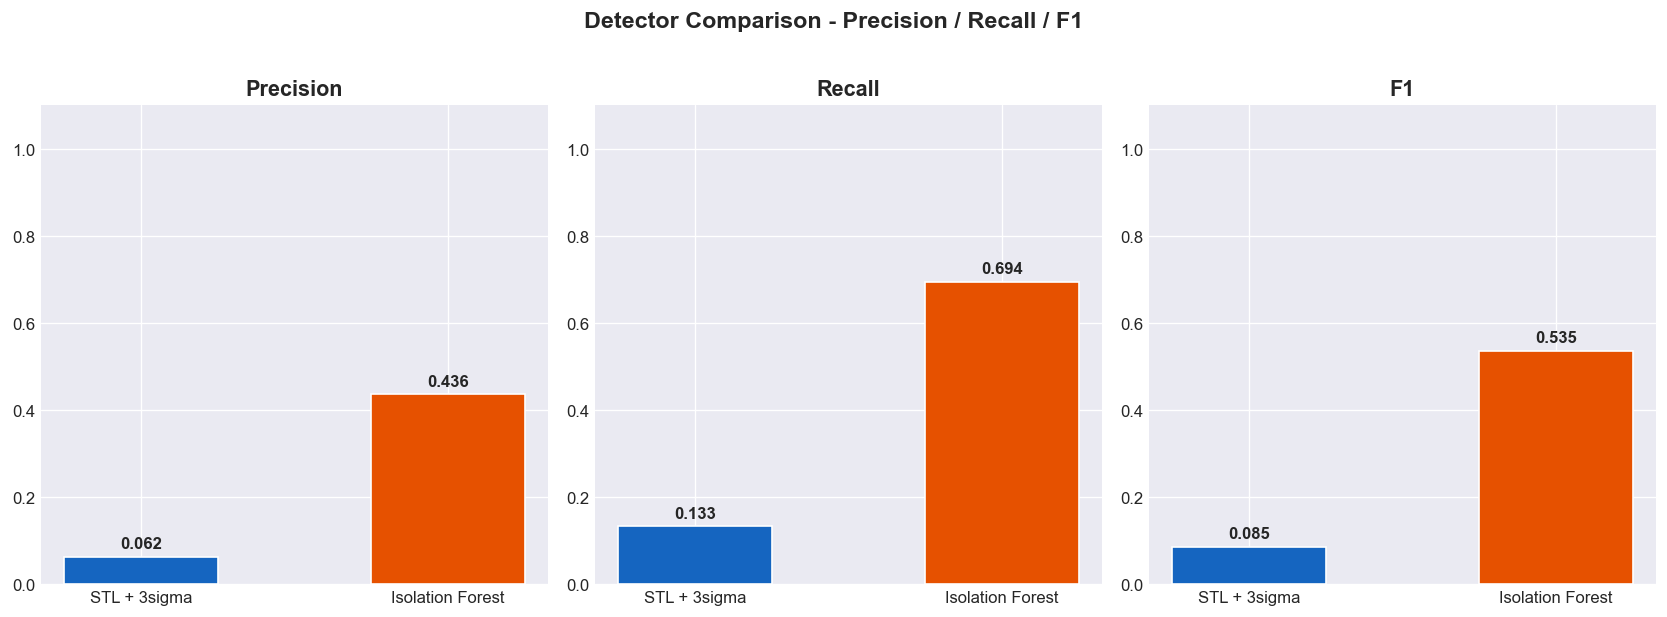

In [20]:
# Bar chart so sanh
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, (name, v1, v2) in enumerate(zip(
    ['Precision', 'Recall', 'F1'],
    [p_stl, r_stl, f1_stl],
    [p_if, r_if, f1_if]
)):
    bars = axes[i].bar(['STL + 3sigma', 'Isolation Forest'], [v1, v2],
                        color=['#1565C0', '#E65100'], edgecolor='white', width=0.5)
    axes[i].set_title(name, fontweight='bold', fontsize=13)
    axes[i].set_ylim(0, 1.1)
    for bar, val in zip(bars, [v1, v2]):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', fontweight='bold')

plt.suptitle('Detector Comparison - Precision / Recall / F1', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_06_comparison_barchart.png', bbox_inches='tight')
plt.show()

### Reflection (Đánh giá và Giải thích)

1. **Dữ liệu thuộc loại gì?**
   * Dữ liệu `ambient_temperature_system_failure` đo nhiệt độ theo thời gian. Nó có tính chu kỳ (Seasonal) dao động theo ngày và đêm, và phân phối tổng thể khá tiệm cận phân phối chuẩn.

2. **Chọn phương pháp nào và tại sao?**
   * **Bước 1 (Statistical):** Vì có chu kỳ nên Z-score bình thường sẽ thất bại. Tôi chọn STL Decomposition để loại bỏ yếu tố mùa vụ (ngày/đêm), sau đó chạy 3-Sigma trên phần residual còn lại để bắt các sai số đột biến.
   * **Bước 2 (ML):** Chọn Isolation Forest (cần Feature Engineering) vì phương pháp này có khả năng nhìn nhận sự kết hợp giữa nhiều bối cảnh cùng lúc (ví dụ: nhiệt độ hôm nay so với trung bình 24h qua và so với cùng giờ ngày hôm qua).

3. **Tại sao STL thất bại nặng nề trên dataset này? (Trade-off & Production choice)**
   * Dữ liệu cung cấp mô tả các đợt hỏng hóc hệ thống làm mát kéo dài trong nhiều ngày.
   * **Tại sao STL miss (Recall thấp 0.133):** Thuật toán STL khi bóc tách chu kỳ đã bị các đoạn nhiệt độ thay đổi từ từ (drift) "đánh lừa". Những đợt lỗi này kéo dài, làm thay đổi hẳn đường xu hướng (Trend). Kết quả là phần residual (dùng để đo 3-Sigma) lại trông có vẻ rất bình thường. STL chỉ giỏi bắt những đốm giật đột ngột (spike), không giỏi bắt các dải lỗi kéo dài.
   * **Tại sao IF thành công hơn hẳn (Recall 0.694, F1 0.535):** Nhờ bước Feature Engineering! Việc thêm các feature như `rolling_mean_24h` và `lag_24` đã giúp Isolation Forest "nhận thức" được rằng toàn bộ dải giá trị trong những ngày hỏng hóc đó không giống với bối cảnh thông thường, giúp nó phát hiện lỗi mượt mà hơn.
   * **Lựa chọn Production:** Với loại lỗi hệ thống biến đổi chậm và kéo dài như thế này, Isolation Forest (với Feature pipeline chuẩn) hoàn toàn áp đảo. Nếu muốn thiên về an toàn hệ thống (không bỏ lọt lỗi), đội vận hành có thể nâng `contamination` lên mức 0.05 (đạt Recall ~90%), chấp nhận xử lý thêm báo động giả (giảm Precision).
